In [31]:
import os
import cv2
import matplotlib.pyplot as plot
import numpy as np

In [25]:
img1_bgr = cv2.imread("images/img1_back_subs.png")
img2_bgr = cv2.imread("images/img2_back_subs.png")

img1 = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)
img2 = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY)

if img1.shape != img2.shape:
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

Klassifiziert50459px
Unklassifiziert699541px
Differenz: 649082px


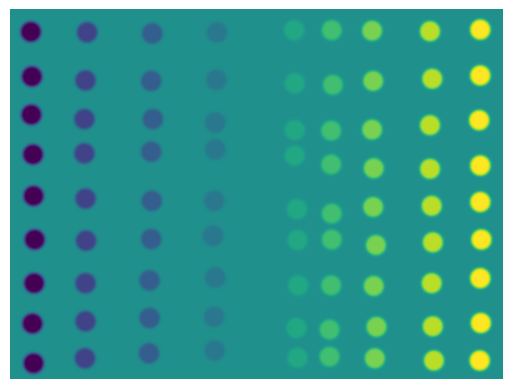

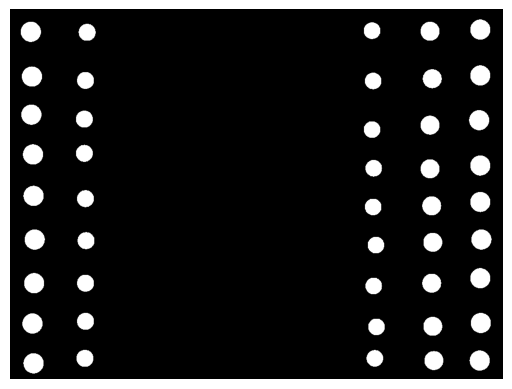

In [58]:
diff = cv2.absdiff(img1, img2)
# cv2.threshold(src, thresh, maxval, type)
_, mask = cv2.threshold(diff, 70, 255, cv2.THRESH_BINARY)

print("Klassifiziert" + str(np.sum(mask == 255)) + "px")
print("Unklassifiziert" + str(np.sum(mask == 0)) + "px")
print("Differenz: " + str(np.sum(mask == 0) - np.sum(mask == 255)) + "px")

plot.figure()
plot.imshow(img2)
plot.axis("off")
plot.show()

plot.figure()
plot.imshow(mask, cmap="gray")
plot.axis("off")
plot.show()

In [60]:
thresholds = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]

diff = cv2.absdiff(img1, img2)

values = []

for thresh in thresholds:
    _, mask = cv2.threshold(diff, thresh, 255, cv2.THRESH_BINARY)

    classified = np.sum(mask == 255)
    unclassified = np.sum(mask == 0)
    difference = np.sum(mask == 0) - np.sum(mask == 255)

    values.append((thresh, int(classified), int(unclassified), int(difference)))
    thresh += 1

print(values)

[(10, 139017, 610983, 471966), (20, 120255, 629745, 509490), (30, 92176, 657824, 565648), (40, 83936, 666064, 582128), (50, 67624, 682376, 614752), (60, 55651, 694349, 638698), (70, 50459, 699541, 649082), (80, 31852, 718148, 686296), (90, 29344, 720656, 691312), (100, 25441, 724559, 699118), (110, 17878, 732122, 714244), (120, 15750, 734250, 718500), (130, 0, 750000, 750000), (140, 0, 750000, 750000), (150, 0, 750000, 750000)]


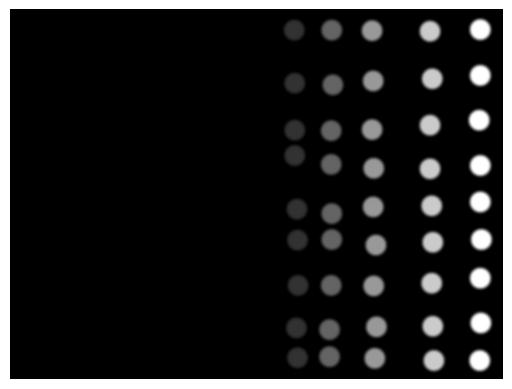

In [ ]:
sub = cv2.subtract(img2, img1) # dunklere werden sichtbar
sub = cv2.subtract(img1, img2) # hellere werden sichtbar

plot.figure()
plot.imshow(sub, cmap="gray")
plot.axis("off")
plot.show()